# Классификация веб-контента: От базовых методов к Deep Learning

Идея: провести сравнительный анализ разных подходов в задаче детекции "запрещенных" сайтов.

Описание задачи: задача состоит в бинарной классификации веб-страниц по их URL и заголовкам.
Нам нужно отделить безопасный контент от категории "для взрослых".

## Data

Данные для проекта взяты из закрытого соревнования. Исходные файлы (train.csv, test.csv) не включены в репозиторий. Вы можете найти их по ссылке: [Porn detection dataset](https://www.kaggle.com/datasets/dulinaira/porn-detection-dataset).

Распакуйте их в папку `/data` в корне проекта.

Или скачайте данные из гугл диска:

In [2]:
!pip install pandas scikit-learn fasttext-wheel nltk jupyterlab sentence-transformers torch matplotlib seaborn pymorphy3 scipy-stubs ipywidgets datasets

In [3]:
import gdown
import os

folder_id = '1RD7s9F2sxg6z_QYxzQHiPxrmtaxzM_rt'

# Параметр use_cookies=False помогает избежать проблем с авторизацией
gdown.download_folder(id=folder_id, output='data', quiet=False, use_cookies=False)

print("Все файлы из папки скачаны в /data")

Retrieving folder contents


Processing file 1v2KpV0t9b5TKGDPN3q8P4cmazfJvk7eT sample_submission.csv
Processing file 1hvA5KmAzr18Ck3VDtofqlztJF_QSqheA test.csv
Processing file 11HXctAInKullrsIGwHGBnQvwZOGgiZDs train.csv
Processing file 1AnkBGvoeyq6Kq0LPKl3PVMerAlegjorI truth2.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1v2KpV0t9b5TKGDPN3q8P4cmazfJvk7eT
To: /content/data/sample_submission.csv
100%|██████████| 1.49M/1.49M [00:00<00:00, 43.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hvA5KmAzr18Ck3VDtofqlztJF_QSqheA
To: /content/data/test.csv
100%|██████████| 22.5M/22.5M [00:00<00:00, 69.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=11HXctAInKullrsIGwHGBnQvwZOGgiZDs
To: /content/data/train.csv
100%|██████████| 18.6M/18.6M [00:00<00:00, 100MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1AnkBGvoeyq6Kq0LPKl3PVMerAlegjorI
To: /content/data/truth2.csv
100%|██████████| 2.76M/2.76M [00:00<00:00, 47.0MB/s]

Все файлы из папки скачаны в /data



Download completed


## EDA (exploratory data analysis)

Посмотрим на изначальный датасет:

In [4]:
import pandas as pd

training_ds = "data/train.csv"

train_df = pd.read_csv(training_ds)
train_df.head()

,ID,url,title,label
0,0,m.kp.md,"Экс-министр экономики Молдовы - главе МИДЭИ, ц...",0
1,1,www.kp.by,Эта песня стала известна многим телезрителям б...,0
2,2,fanserials.tv,Банши 4 сезон 2 серия Бремя красоты смотреть о...,0
3,3,colorbox.spb.ru,Не Беси Меня Картинки,0
4,4,tula-sport.ru,В Новомосковске сыграют следж-хоккеисты алекси...,0


In [5]:
train_df.shape

(135309, 4)

In [6]:
train_df['label'].value_counts()

,count
label,
0,118594
1,16715


Особенности данных: мы имеем дело с сильно несбалансированной выборкой и короткими текстовыми фрагментами (заголовки, домены).

In [7]:
# Тестовая выборка
test_df = pd.read_csv("data/test.csv")
truth_df = pd.read_csv("data/truth2.csv")
test_df['true_label'] = truth_df['label']

In [8]:
test_df.head()

,ID,url,title,true_label
0,135309,www.kommersant.ru,Шестой кассационный суд в Самаре начнет работу...,0
1,135310,urexpert.online,"Что такое индексация алиментов, кем и в каких ...",0
2,135311,imperimeha.ru,Женщинам | Империя Меха - Part 12,0
3,135312,national-porn.com,"Небритые, волосатые киски: Порно всех стран и ...",1
4,135313,2gis.ru,67,0


In [9]:
def accuracy_sc(*, tp, tn, fp, fn):
    return (tp + tn) / (tp + tn + fp + fn)
def precision_sc(*, tp, fp):
    return tp / (tp + fp + 1e-9)
def recall_sc(*, tp, fn):
    return tp / (tp + fn + 1e-9)

def f1_sc(*, precision, recall):
    return 2 * (precision * recall) / (precision + recall + 1e-9)

## TF-IDF

### Препроцессинг

К TF-IDF, который подсчитывает количество слов, применим леммитазацию, чтобы разные формы слова считались одним целым

In [10]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
import pymorphy3

# Загружаем стоп-слова (предлоги, союзы и т.д., которые не несут смысла)
nltk.download('stopwords')
stop_words = set(stopwords.words('russian')).union(set(stopwords.words('english')))

morph = pymorphy3.MorphAnalyzer()

# Создаем словарь(кэш), чтобы не лемматизировать одно и то же слово дважды
lemma_cache = {}

def clean_and_lemmatize(text):
    text = str(text).lower()

    text = re.sub(r'[^a-zа-яё]', ' ', text)

    words = text.split()
    lemmas = []

    for w in words:
        if w in stop_words:
            continue # Пропускаем мусорные слова

        if w not in lemma_cache:
            # Лемматизируем только если слова нет в кэше
            lemma_cache[w] = morph.parse(w)[0].normal_form

        lemmas.append(lemma_cache[w])

    return " ".join(lemmas)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Очищаем обучающую выборку

In [11]:
train_url_clean = train_df['url'].apply(clean_and_lemmatize)
train_title_clean = train_df['title'].apply(clean_and_lemmatize)

Очищаем тестовую выборку

In [12]:
test_url_clean = test_df['url'].apply(clean_and_lemmatize)
test_title_clean = test_df['title'].apply(clean_and_lemmatize)

Создаем два отдельных векторизатора для `url` и для `title`

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_url = TfidfVectorizer(max_features=50000)
vectorizer_title = TfidfVectorizer(max_features=100000, ngram_range=(1, 2))

Векторизируем url

In [14]:
X_train_url = vectorizer_url.fit_transform(train_url_clean)
X_test_url  = vectorizer_url.transform(test_url_clean)

Векторизируем title

In [15]:
X_train_title = vectorizer_title.fit_transform(train_title_clean)
X_test_title  = vectorizer_title.transform(test_title_clean)

Интересно посмотреть на самые редкие слова

In [16]:
idf_df = pd.DataFrame({'word': vectorizer_title.get_feature_names_out(),
                       'idf_weight': vectorizer_title.idf_})

print("Самые редкие слова:")
print(idf_df.sort_values(by='idf_weight', ascending=False).head(10))

print("\nСамые частотные слова (низкий IDF):")
print(idf_df.sort_values(by='idf_weight', ascending=True).head(10))


Самые редкие слова:
                          word  idf_weight
75039    проектирование мебель   12.122177
25934  автомобиль автозапчасть   12.122177
89727       стихотворение блок   12.122177
56335           ленинград вояж   12.122177
47216          история религия   12.122177
60853          миасс витязёвый   12.122177
89738               сто суметь   12.122177
89736            стк логистика   12.122177
8895                gaming sli   12.122177
39138    дистрибьютор circutor   12.122177

Самые частотные слова (низкий IDF):
            word  idf_weight
20523         ru    3.271086
67358     онлайн    3.444822
28479  бесплатно    3.810901
85408    скачать    3.885359
97202       цена    3.983028
15933       mail    3.999064
15934    mail ru    4.014306
54860     купить    4.039620
70990      поиск    4.053460
86647   смотреть    4.092092


Склеиваем (hstack) матрицы признаков по горизонтали

In [17]:
from scipy.sparse import hstack

X_train_combined = hstack([X_train_url, X_train_title])
X_test_combined  = hstack([X_test_url, X_test_title])

### Обучение

In [18]:
all_feature_names = list(vectorizer_url.get_feature_names_out()) + list(vectorizer_title.get_feature_names_out())

row = X_train_combined[0]

word_values = [
    (all_feature_names[i], row.data[idx])
    for idx, i in enumerate(row.indices)
]

word_values.sort(key=lambda x: x[1], reverse=True)

for word, score in word_values:
    print(f"Слово: {word:20} | Вес TF-IDF: {score:.4f}")

Слово: md                   | Вес TF-IDF: 0.7227
Слово: kp                   | Вес TF-IDF: 0.6912
Слово: который сделать      | Вес TF-IDF: 0.3317
Слово: донор                | Вес TF-IDF: 0.3270
Слово: избегать             | Вес TF-IDF: 0.3230
Слово: нахождение           | Вес TF-IDF: 0.3084
Слово: долгий               | Вес TF-IDF: 0.2954
Слово: министр              | Вес TF-IDF: 0.2761
Слово: экс                  | Вес TF-IDF: 0.2717
Слово: молдова              | Вес TF-IDF: 0.2650
Слово: цель                 | Вес TF-IDF: 0.2534
Слово: экономика            | Вес TF-IDF: 0.2334
Слово: республика           | Вес TF-IDF: 0.2121
Слово: сделать              | Вес TF-IDF: 0.2087
Слово: который              | Вес TF-IDF: 0.1931
Слово: глава                | Вес TF-IDF: 0.1774


Что мы имеем? Огромную матрицу one-hot encoded, где присутствие слова в тексте кодируется его TF-IDF весом.

Обучать будем на такой матрице базовую модель - логистическую регрессию. Причины:
* В отличие от FastText или BERT, в логистической регрессии мы можем четко увидеть веса каждого слова и понять, почему модель приняла то или иное решение.
* Интересно будет в конце сравнить классический алгоритм с FastText и BERT.

In [19]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

In [20]:
%%time

lr_model.fit(X_train_combined, train_df['label'])

CPU times: user 5.7 s, sys: 22.5 ms, total: 5.72 s
Wall time: 3.03 s


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Предсказание

In [21]:
y_pred_tf_idf = lr_model.predict(X_test_combined)
test_df['tfidf_label'] = y_pred_tf_idf

### Метрики

In [22]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(test_df['true_label'], y_pred_tf_idf).ravel()
accuracy = accuracy_sc(tp=tp, tn=tn, fp=fp, fn=fn)
precision = precision_sc(tp=tp, fp=fp)
recall = recall_sc(tp=tp, fn=fn)
f1 = f1_sc(precision=precision, recall=recall)

tfidf_results = {
    'Model': 'TF-IDF + LogReg',
    'Accuracy': round(accuracy, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1-score': round(f1, 4)
}

results_table = pd.DataFrame([tfidf_results])
display(results_table)

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + LogReg,0.9867,0.9232,0.9734,0.9476


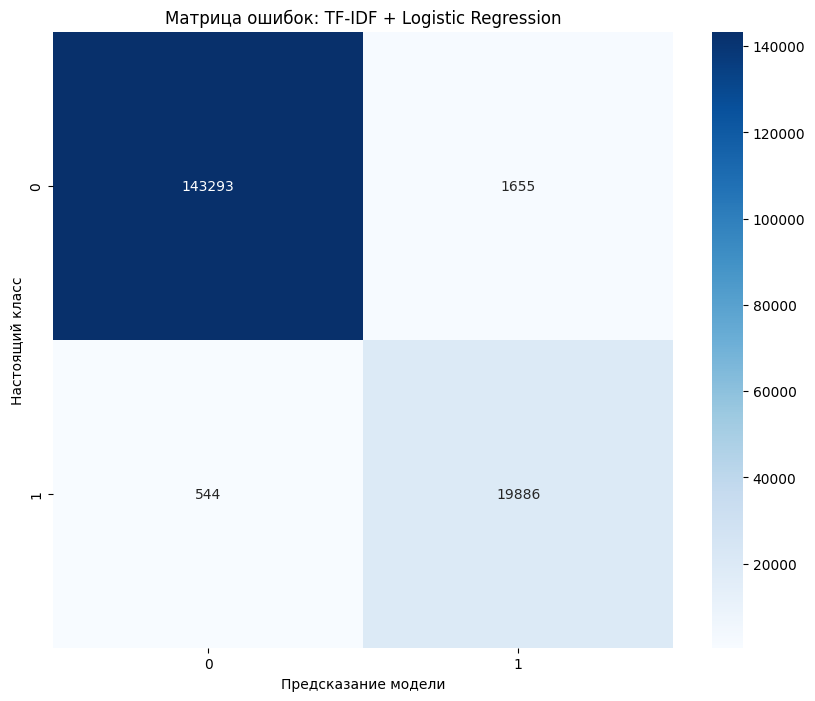

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

tdidf_cm = confusion_matrix(test_df['true_label'], y_pred_tf_idf)

plt.figure(figsize=(10, 8))
sns.heatmap(tdidf_cm, annot=True, fmt='d', cmap='Blues')

plt.title('Матрица ошибок: TF-IDF + Logistic Regression')
plt.ylabel('Настоящий класс')
plt.xlabel('Предсказание модели')
plt.show()

In [24]:
errors_df =test_df[test_df['tfidf_label'] != test_df['true_label']]
print(f"Всего совершено ошибок: {len(errors_df)} из {len(truth_df)} примеров\n")
errors_df.head()

for idx, row in errors_df.sample(5, random_state=42).iterrows():

    text = f"{row.get('title', '')} | {row.get('url', '')}"

    print(f"Text: {text}")
    print(f"True: {row['true_label']}")
    print(f"Predicted: {row['tfidf_label']}")
    print("="*60)

Всего совершено ошибок: 2199 из 165378 примеров

Text: Футболка мужская с длинным рукавом, Женский трикотаж, халаты женские, женские ко... | marlentex.com
True: 0
Predicted: 1
Text: “Onlara ömürlük cəza...” – | teleqraf.com
True: 0
Predicted: 1
Text: Vk Real Incest Videos | www.milan-salone.ru
True: 1
Predicted: 0
Text: Clip Art Bikes Clipart Best - Foto | fotocars.com
True: 0
Predicted: 1
Text: 13.07.2019 | bomjstarter.com
True: 0
Predicted: 1


**ВЫВОД**:

Ключевые особенности реализации:

- Использован раздельный подход к обработке признаков: колонки URL и Title обрабатывались независимыми векторизаторами, после чего объединялись в единую разреженную матрицу через hstack. Это позволило модели учитывать разную значимость слов в адресе сайта и в его заголовке.
- Для борьбы с дисбалансом классов (NSFW-контента значительно меньше) был применен параметр class_weight='balanced'.
- Включение n-грамм (размером от 1 до 2 слов) позволило модели улавливать устойчивые словосочетания, повысив тем самым точность на специфических тематиках.

Результаты:

-  F1-score (Macro) на тестовой выборке составил `0.9476`.
- Accuracy модели: `0.9867`.
- Количество ошибок: `2199`

Наблюдения и анализ ошибок:

- Модель показала отличные результаты в выявлении характерных слов-маркеров, благодаря их высокому весу в TF-IDF.
- При анализе ошибок (Error Analysis) было выявлено, что модель иногда ошибается на очень коротких заголовках, где TF-IDF веса недостаточно велики для уверенного решения.
- Также обнаружены случаи «шума» в исходной разметке данных, где модель верно классифицировала подозрительный контент, хотя в разметке он был помечен как безопасный.

## FastText

In [25]:
import fasttext

FastText - библиотека для обучения векторных представлений слов и классификации текста, созданная лабораторией AI Research (FAIR) Facebook.

Она разделяет слова на n-граммы, а векторное представление самого слова вычисляет как сумму ембеддингов этих n-грамм.

### Препроцессинг

In [26]:
# Объединяем URL и заголовок в один текст (фичи)
X = train_df['url'].fillna('') + ' ' + train_df['title'].fillna('')

# таргет
y = train_df['label']

Разрезаем длинные строки на слова (токены), а также применяем стемминг - удаление окончаний слова, чтобы разные формы одно и того же слова относились к одному понятию:

In [27]:
import re
from nltk.stem.snowball import SnowballStemmer

stemmer = SnowballStemmer("russian")
def tokenizer(text):
    text = text.lower()

    parts = text.split(' ', 1) # url and title
    url_part = parts[0]
    title_part = parts[1] if len(parts) > 1 else ""

    # Убираем протоколы и www в начале
    url_part = re.sub(r'^(https?://)?(www\.)?', '', url_part)
    # Разбиваем домен на части по точкам
    domain_pieces = url_part.split('.')

    boring_tlds = {'ru', 'com', 'net', 'org', 'by', 'md', 'ua', 'online', 'spb', 'net'}
    url_tokens = [p for p in domain_pieces if p not in boring_tlds and len(p) >= 3]

    # В заголовке разрешаем слова от 3 символов
    title_tokens = re.findall(r'[а-яА-Яa-zA-Z]{3,}', title_part)

    final_tokens = [stemmer.stem(t) for t in (url_tokens + title_tokens)]

    return final_tokens

Делим `train.csv` на обучающую и валидационную выборки для оценки модели во время обучения

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y,
                                                    test_size=0.2, random_state=42)

Для FastTest нужно привести метки к виду `__label__<n>`

In [29]:
# подготовим файлы с датасетами для фасттекста
train_df["label_ft"] = train_df["label"].apply(lambda x: "__label__" + str(x))
train_df.head()

,ID,url,title,label,label_ft
0,0,m.kp.md,"Экс-министр экономики Молдовы - главе МИДЭИ, ц...",0,__label__0
1,1,www.kp.by,Эта песня стала известна многим телезрителям б...,0,__label__0
2,2,fanserials.tv,Банши 4 сезон 2 серия Бремя красоты смотреть о...,0,__label__0
3,3,colorbox.spb.ru,Не Беси Меня Картинки,0,__label__0
4,4,tula-sport.ru,В Новомосковске сыграют следж-хоккеисты алекси...,0,__label__0


In [30]:
X_train_clean = X_train.apply(lambda x: ' '.join(tokenizer(str(x))))

In [31]:
X_train[:5], X_train_clean[:5]

(36898     karat.spb.ru Амиксидин: продажа, цена в Санкт-...
 69667                        samara.farfor.ru Ультрасет new
 111124    www.zr.ru Lada Vesta Cross: видеообзор с презе...
 35818     xn----htbdmodofzkc0c.xn--p1ai Фрезерный станок...
 123149    porno365.co Популярное порно по просмотрам - п...
 dtype: object,
 36898     karat амиксидин продаж цен санкт петербург мед...
 69667                           samara farfor ультрасет new
 111124    lada vesta cross видеообзор презентац серийн м...
 35818     xn----htbdmodofzkc0c xn--p1ai фрезерн станок м...
 123149    porno365 популярн порн просмотр порнух популяр...
 dtype: object)

In [32]:
X_valid_clean = X_valid.apply(lambda x: ' '.join(tokenizer(str(x))))

In [33]:
X_valid_clean[:5]

,0
54589,kinotrast сериа качел белар все сер смотрет он...
41071,pc01 шкаф спальн гарнитур энрик руб грозн анал...
19161,forum zoneofgames swat close quarters battle р...
75429,librebook чита онлайн электрон книг промет ил ...
121091,meduniver как науч щедрост собствен мужчин оту...


In [34]:
train_ds = pd.concat([X_train_clean.apply(lambda x: re.sub('\t', '', x)),
                           y_train.apply(lambda x: '__label__' + str(x))], axis=1)

valid_ds = pd.concat([X_valid_clean.apply(lambda x: re.sub('\t', '', x)),
                          y_valid.apply(lambda x: '__label__' + str(x))], axis=1)

Чтобы улучшить метрики модели, мы будем насильно штрафовать её за ошибки ещё больше раз, для этого хардкорно продублируем данные с меткой label = 1.

In [35]:
minority_class = train_ds[train_ds.iloc[:, 1] == '__label__1']
print(minority_class[0])

oversampled_data = pd.concat([train_ds, minority_class, minority_class, minority_class, minority_class], axis=0)

# Перемешиваем данные
oversampled_data = oversampled_data.sample(frac=1, random_state=42).reset_index(drop=True)

123149    porno365 популярн порн просмотр порнух популяр...
131576         erkiss2 порва пизд красив блондинк порн виде
28367     daftsex watchingmymomgoblack nicole moore big ...
46206     lerporn брюнетк порн онлайн страниц брюнетк по...
40191     berufsbildungsbericht info nudist mother son p...
                                ...                        
56886     xnxxn pro russian category page free porn sex ...
65725     sex-za-dengi порн ебл груд красив деньг смотре...
123855                   oxporno популярн порн виде телефон
126324    sex-kadr гол ренат литвинов смотрет онлайн вид...
110268                pornophoto pro смотрет брит вагин фот
Name: 0, Length: 13375, dtype: object


In [36]:
print(f"Было строк: {len(train_ds)}")
print(f"Стало строк после дублирования: {len(oversampled_data)}")
print(f"Распределение классов: {train_ds['label'].value_counts(0)}")

Было строк: 108247
Стало строк после дублирования: 161747
Распределение классов: label
__label__0    94872
__label__1    13375
Name: count, dtype: int64


In [37]:
train_ds = oversampled_data

`train_ds` — это просто таблица (DataFrame).
Чтобы FastText начал учиться, эту таблицу нужно сохранить в текстовый файл без лишних кавычек и запятых.

In [38]:
import os
os.makedirs("fasttext", exist_ok=True)

train_ds.to_csv("fasttext/train_ds.txt", sep='\t', header=None, index=None)
valid_ds.to_csv("fasttext/valid_ds.txt", sep='\t', header=None, index=None)

In [39]:
with open("fasttext/train_ds.txt", "r", encoding="utf-8") as f:
    for _ in range(5): # Выведет первые 5 строк
        print(f.readline().strip())

liebelib yas xxx vidio first time porn tube videos	__label__1
xn----itbooccbfegeay русск инцест русск порн инцест виде страниц	__label__1
genderi tarihi yeri stanbul renim durumu	__label__0
perfectgirls anal porn perfect girls	__label__1
prom подвесн нсп цен грн куп николаев prom	__label__0


### Обучение

In [40]:
%%time
model = fasttext.train_supervised(
    input="fasttext/train_ds.txt",
    epoch=14,
    lr = 0.4,
    # minCount=5,  # отсеиваем редкие токены
    minn=3, maxn=6,  # диапазон для символьных нграмм
    wordNgrams=5,  # используем словесные нграммы размера 2
    dim=45,  # размер вектора для каждого слова/кусочка
    bucket=350000, # количество бакетов для хеширования, услоно на что делится хэш
    loss='ova', # sigmoid
) # логи обучения пишутся в терминале

CPU times: user 1min 2s, sys: 341 ms, total: 1min 2s
Wall time: 1min 10s


Метрики на валидационной выборке

In [41]:
n, p, r = model.test("fasttext/valid_ds.txt")

In [42]:
print(f"N: {n}\nPrecision: {p}\nRecall: {r}\nF1: {f1_sc(precision=p, recall=r)}")

N: 27062
Precision: 0.9963786859803414
Recall: 0.9963786859803414
F1: 0.9963786854803414


### Предсказание

In [43]:
X_final = (test_df['url'].fillna('') + ' ' + test_df['title'].fillna(''))
X_final = X_final.apply(lambda x: ' '.join(tokenizer(str(x)))).tolist()

Наконец предсказываем

In [44]:
# k=1 - берем только один самый вероятный класс
labels, predictions = model.predict(X_final, k=1)

In [45]:
print(labels[0], predictions[0])

['__label__0'] [1.00001]


In [46]:
test_df['ft_label'] = [int(l[0].replace('__label__', '')) for l in labels]

Собираем метрики с тестовой выборки

In [47]:
y_true = test_df['true_label']
y_pred = test_df['ft_label']

In [48]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

precision = precision_sc(tp = tp, fp=fp)
recall = recall_sc(tp=tp, fn=fn)
fasttext_metrics = {
    'Model': 'FastText',
    'Accuracy': round(accuracy_sc(tp=tp, tn=tn, fp=fp, fn=fn), 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1-score': round(f1_sc(precision = precision, recall = recall), 4)
}

results_table = pd.DataFrame([fasttext_metrics])
# Выводим красивую итоговую таблицу
display(results_table) # 0.9967 0.9902 0.9828 0.9865

,Model,Accuracy,Precision,Recall,F1-score
0,FastText,0.9967,0.9905,0.9826,0.9865


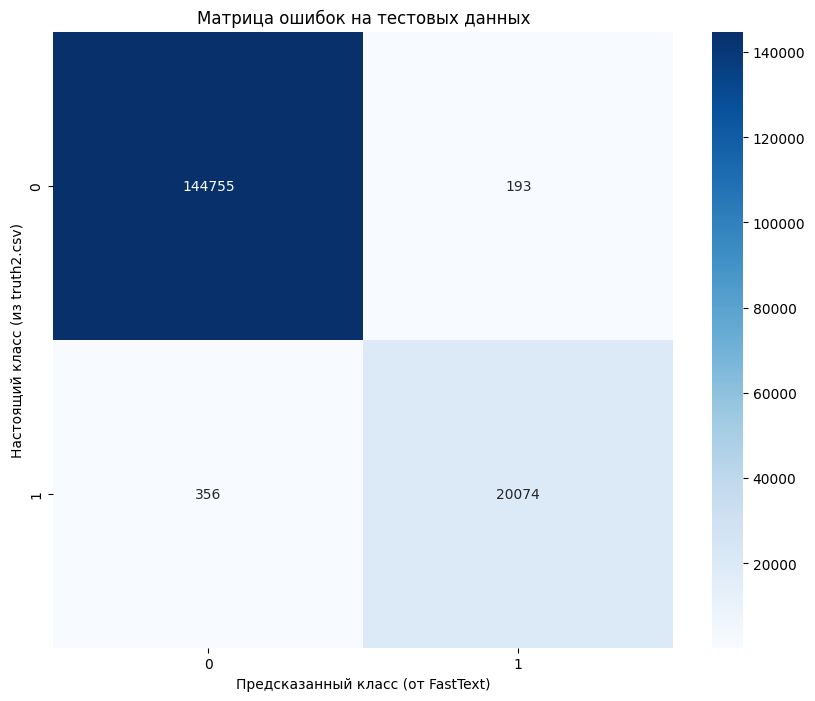

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

ft_cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(ft_cm, annot=True, fmt='d', cmap='Blues')

plt.title('Матрица ошибок на тестовых данных')
plt.ylabel('Настоящий класс (из truth2.csv)')
plt.xlabel('Предсказанный класс (от FastText)')
plt.show()

In [50]:
errors_df =test_df[test_df['ft_label'] != test_df['true_label']]
print(f"Всего совершено ошибок: {len(errors_df)} из {len(truth_df)} примеров\n")
errors_df.head()

Всего совершено ошибок: 549 из 165378 примеров



,ID,url,title,true_label,tfidf_label,ft_label
675,135984,4ertik.cc,"Трахаются в магазине, как кролики",1,1,0
840,136149,pressa.tv,Любвеобильная девушка и друг,0,1,1
968,136277,rykodelie-dlay-vsex.ru,Открытки вытынанки к новому году своими руками,1,0,0
1656,136965,wondersex.ru,Доминирующая женщина 47 лет ищет нижнего партн...,1,1,0
1766,137075,seksi-new.online,Она похожа на меня / She Looks Like Me (2013),1,0,0


In [51]:
for idx, row in errors_df.sample(10, random_state=42).iterrows():

    text = f"{row.get('title', '')} | {row.get('url', '')}"

    print(f"Text: {text}")
    print(f"True: {row['true_label']}")
    print(f"Predicted: {row['ft_label']}")
    print("="*60)

Text: Добавление аудио | img.movavi.com
True: 1
Predicted: 0
Text: ❤ Сладкий отсосик - ☎ секс по телефону! | www.otsosik.com
True: 0
Predicted: 1
Text: Потрахаться в киску. Надия, Домодедово | domodedovo.volkhov-kszn.ru
True: 0
Predicted: 1
Text: Секс тани с универа с сашей, саша таня смотреть онлайн ВКонтакте | xn--l1affk.xn--p1ai
True: 1
Predicted: 0
Text: мои фото* / Фото - Spaces.ru / Spcs.me | spcs.me
True: 1
Predicted: 0
Text: Сужающий гель для женщин Spring Touch - 50 мл. Erotist Lubricants купить в магазине эротического белья SweetSecrets.ru | www.sweetsecrets.ru
True: 0
Predicted: 1
Text: Управление сайтом - Конвертор файлов | pornogoda.com
True: 1
Predicted: 0
Text: 153 | domahi.com
True: 1
Predicted: 0
Text: хочу секса - Поиск Mail.Ru | mail.ru
True: 0
Predicted: 1
Text: UFBW-2101 Megumi Tamura 田村芽実 – May. » Blog Idols Original - X-IDOL Video Blog Gravure IDOL | blog.aidol.asia
True: 0
Predicted: 1


**ВЫВОД:**

В ходе работы была обучена модель FastText в режиме обучения с учителем (supervised). Главное преимущество данного метода — работа не только с целыми словами, но и с символьными n-граммами (подсловами), что дает устойчивость к опечаткам и позволяет обрабатывать слова, которых не было в обучающей выборке.

Метрики качества:
- F1-score: `0.9865`
- Accuracy: `0.9967`
- Кол-во ошибок: `549`

Анализ:

- Модель ошибочно классифицировала новостную статью сайта Glavred как «взрослый контент» (False Positive). Это произошло из-за высокой концентрации слов-маркеров. FastText, работая на уровне n-грамм, видит эти слова, но не учитывает общий новостной контекст статьи. Это ограничение «мешка слов» — модель не понимает, что текст описывает событие, а не предоставляет сам контент.

- Шум и спорная разметка данных (Data Quality):
    В нескольких примерах (например, с сайтами HDReactor или Blog Idols) модель предсказала класс 1 (NSFW), в то время как в истинной разметке стоял класс 0. Анализируя текст (заголовки про "Naturals", "Idol", "Gravure"), можно сделать вывод, что модель оказалась точнее разметки. В данных присутствует заметный шум, что искусственно занижает итоговые метрики модели.

- Проблема коротких текстов и отсутствие данных:
    Примеры с заголовками типа «60» или «153» модель относит к безопасному классу, даже если домен является сомнительным (3gpjizz.mobi). При отсутствии содержательного текста модели катастрофически не хватает n-грамм для принятия решения.

Итоговое мнение: FastText показал высокую скорость работы (`~8 сек`) и отличную способность находить закономерности в самих словах и их частях. Однако для отделения «новостей о контенте» от «самого контента» модели недостаточно семантического понимания, что является точкой роста для использования более тяжелых моделей (например, BERT).

## BERT (fine-tuning)

**BERT** - Bidirectional Encoder Representations from Transformers. В отличие от предыдущих методов, BERT учитывает порядок слов и их взаимосвязи. В отличие от тех же RNN transformers используют метод attention и принимают во внимание всё предложение целиком, а не слово за словом. Если быть точнее, то всё благодаря двунаправленности (Bidirectional), BERT на каждом слое видит одновременно и левый, и правый контекст слова. Это позволяет ему различать тонкие нюансы: например, понять, что новость на «Главреде» — это журналистика, а не порнография, просто по структуре предложений и контекстуальным связям слов.

Мы проведем Fine-tuning — дообучим предобученную на миллионах текстов модель именно под нашу специфику (классификация URL и заголовков).

In [52]:
from transformers import AutoTokenizer

model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

### Препроцессинг

Снова выделим из обучающей выборки валидационную:

In [53]:
from sklearn.model_selection import train_test_split

train_sub, val_sub = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

In [54]:
def tokenize_function(examples):
    # Склеиваем url и title, как делали раньше
    texts = [f"{t} {u}" for t, u in zip(examples["title"], examples["url"])]
    return tokenizer(texts, padding="max_length", truncation=True, max_length=128)

Создаем объекты Dataset из pandas

In [55]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_sub[['title', 'url', 'label']])
val_ds = Dataset.from_pandas(val_sub[['title', 'url', 'label']])

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_val = val_ds.map(tokenize_function, batched=True)

tokenized_test = Dataset.from_pandas(test_df).map(tokenize_function, batched=True)

Map:   0%|          | 0/108247 [00:00<?, ? examples/s]

Map:   0%|          | 0/27062 [00:00<?, ? examples/s]

Map:   0%|          | 0/165378 [00:00<?, ? examples/s]

### Обучение

In [56]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Гиперпараметры
training_args = TrainingArguments(
    output_dir="./bert_results",
    learning_rate=2e-5, # рекомендации самих авторов BERT из Google
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01, # регуляризация
    eval_strategy="epoch", # провекра после каждой эпохи
    save_strategy="no",
    report_to="none"
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
)

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

In [57]:
%%time

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.031050,0.022878
2,0.016103,0.019481
3,0.011804,0.020189


CPU times: user 11min 39s, sys: 4.84 s, total: 11min 44s
Wall time: 11min 58s


TrainOutput(global_step=20298, training_loss=0.02703391792668722, metrics={'train_runtime': 718.5785, 'train_samples_per_second': 451.921, 'train_steps_per_second': 28.247, 'total_flos': 598676836898304.0, 'train_loss': 0.02703391792668722, 'epoch': 3.0})

### Предсказание

In [58]:
import numpy as np

# Получаем предсказания
predictions = trainer.predict(tokenized_test)
y_pred_bert = np.argmax(predictions.predictions, axis=-1)

In [59]:
test_df['bert_label'] = y_pred_bert

Собираем метрики с тестовой выборки

In [60]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(test_df['true_label'], y_pred_bert).ravel()

precision = precision_sc(tp = tp, fp=fp)
recall = recall_sc(tp=tp, fn=fn)
bert_metrics = {
    'Model': 'BERT',
    'Accuracy': round(accuracy_sc(tp=tp, tn=tn, fp=fp, fn=fn), 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1-score': round(f1_sc(precision = precision, recall = recall), 4)
}

results_table = pd.DataFrame([bert_metrics])

display(results_table)

,Model,Accuracy,Precision,Recall,F1-score
0,BERT,0.9956,0.9861,0.9783,0.9822


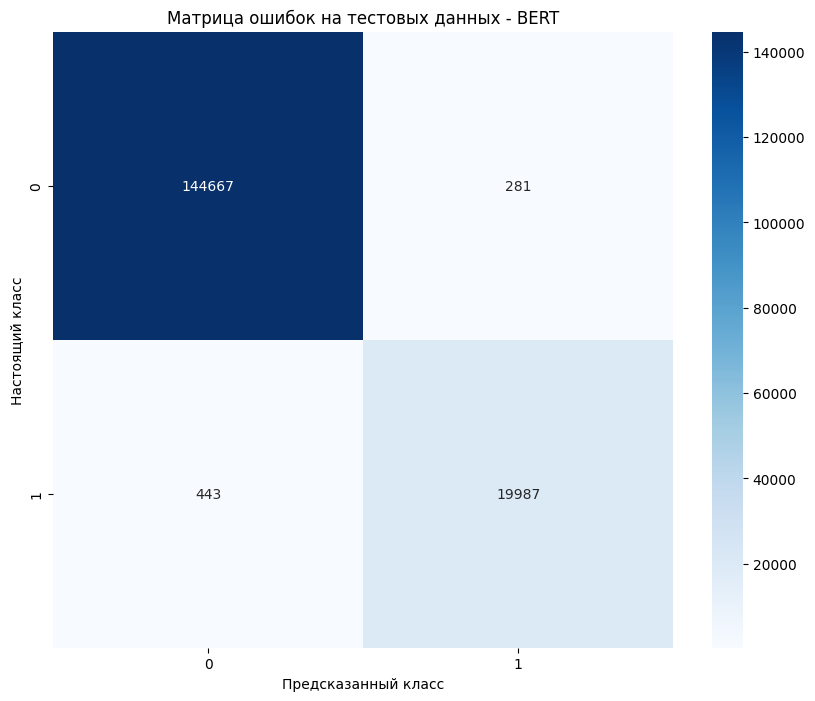

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

bert_cm = confusion_matrix(test_df['true_label'], y_pred_bert)
plt.figure(figsize=(10, 8))
sns.heatmap(bert_cm, annot=True, fmt='d', cmap='Blues')

plt.title('Матрица ошибок на тестовых данных - BERT')
plt.ylabel('Настоящий класс')
plt.xlabel('Предсказанный класс')
plt.show()

In [62]:
errors_df =test_df[test_df['bert_label'] != test_df['true_label']]
print(f"Всего совершено ошибок: {len(errors_df)} из {len(truth_df)} примеров\n")
errors_df.head()

Всего совершено ошибок: 724 из 165378 примеров



,ID,url,title,true_label,tfidf_label,ft_label,bert_label
41,135350,replyua.net,«За*бала уже со своим п**даком жирным»: секс –...,0,1,0,1
82,135391,xmovies24.cc,General – xMovies24,0,1,0,1
675,135984,4ertik.cc,"Трахаются в магазине, как кролики",1,1,0,0
706,136015,text.xstory.ru,Эротические рассказы и истории - Письма читате...,1,1,1,0
840,136149,pressa.tv,Любвеобильная девушка и друг,0,1,1,1


In [63]:
for idx, row in errors_df.sample(10, random_state=42).iterrows():

    text = f"{row.get('title', '')} | {row.get('url', '')}"

    print(f"Text: {text}")
    print(f"True: {row['true_label']}")
    print(f"Predicted: {row['bert_label']}")
    print("="*60)

Text: Эта стройная телочка сама записала как она купается в душе на камеру | grand-chlen.ru
True: 1
Predicted: 0
Text: Домашнее 18  Трах в машине Ебля Хорошо попрыгала сучка | spree.link
True: 0
Predicted: 1
Text: Изнасиловал служанку за провинность | m.potaskushka.com
True: 1
Predicted: 0
Text: Jack Harrer & Garret Dornan » Gay Raw Club | gayrawclub.com
True: 1
Predicted: 0
Text: отчим трахает дочку дашу - 510 тыс. результатов. Поиск Mail.Ru | mail.ru
True: 0
Predicted: 1
Text: Imagefap saggy empty tits-nude galerie | papilloma-virus.com
True: 1
Predicted: 0
Text: Just a moment... | ocobehefuwor.cf
True: 1
Predicted: 0
Text: #манга@two_man_having_sex. #ГРЯМ. Взор мёртвого ворона | Gaze of Dead Raven | Jugeun Kkamagwiui Siseon | interesnoe.me
True: 0
Predicted: 1
Text: French Montana feat. City Girls — Wiggle It | zaycev.net
True: 1
Predicted: 0
Text: Image Scanner | imagescanner.cc
True: 1
Predicted: 0


**ВЫВОД**:

Метрики качества:
- F1-score: `0.9822`
- Accuracy: `0.9956`
- Кол-во ошибок: `724`

Анализ:
- Исправление ошибок разметки (BERT vs Dataset):

  Подавляющее большинство False Positive ошибок BERT на самом деле оказались верными предсказаниями. Есть примеры, которые ИЗНАЧАЛЬНО БЫЛИ ОШИБОЧНО ПОМЕЧЕНЫ в датасете как класс «0» (Safe). BERT, благодаря своему языковому предобучению, легко распознал их суть и предсказал класс «1» (NSFW). Это доказывает, что реальная точность модели гораздо выше зафиксированной метрики, а "ошибки" вызваны шумом в тестировочных данных.

- Языковая чувствительность:

  Было замечено, что модель иногда допускает ошибки на текстах на славянских или других европейских языках (польский, сербский, испанский), классифицируя обычный бытовой контент как подозрительный. Это может быть связано с тем, что в обучающей выборке было меньше примеров на этих языках, чем на русском и английском.

In [64]:
import pandas as pd

# Собираем данные
comparison_data = [tfidf_results,fasttext_metrics, bert_metrics]
results_df = pd.DataFrame(comparison_data)

# Сортируем по F1-score
results_df = results_df.sort_values(by='F1-score', ascending=False)

display(results_df)


,Model,Accuracy,Precision,Recall,F1-score
1,FastText,0.9967,0.9905,0.9826,0.9865
2,BERT,0.9956,0.9861,0.9783,0.9822
0,TF-IDF + LogReg,0.9867,0.9232,0.9734,0.9476


Хотя F1-score модели FastText формально выше, анализ ошибок показывает, что FastText просто «лучше подстроился» под зашумленные данные и специфические строковые паттерны. BERT же продемонстрировал более глубокое понимание смысла текста, что делает его более надежным в реальных условиях, когда на вход поступают тексты, не встречавшиеся в обучающей выборке.